# Project 1 - 2026

Work in groups of 2-5. Prepare ~10 slides where one slide describes your setup and analysis, main results, challenges/suprises and take-home message.

Everyone should do the first part of the project. You can then choose from one of the three themes for part 2.

You will be working with a subset of the MNIST data set. 

For all tasks, you have to repeat the exercise in order to be able to draw conclusions. That is, one single run of a data analysis task or simulation has very limited information so repeat a few times to ensure you are not drawing conclusions based on a random "fluke".

## Introduction

The first time when looking at a csv dataset, it can be benefical to load it in using pandas, to get a sense of the datas content.

Shape images (before): (10000, 784)
Shape labels (before): (10000, 1)
Shape images (after): (2000, 784)
Shape labels (after): (2000, 1)


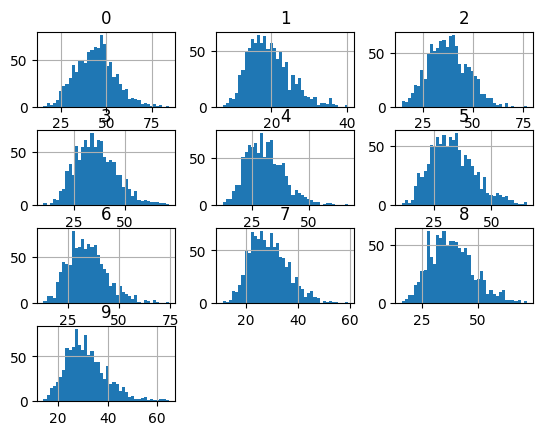

In [1]:
# To run this notebook yourself, the data needs to be unzipped and 
# the path variable specified to point to the unzipped data folder.
# Here we place it in the same folder as the zipped data.

import pandas as pd

PATHIM = "mnist_large//images.csv"
PATHLB = "mnist_large//labels.csv"

images = pd.read_csv(PATHIM, sep=",", index_col=0)
labels = pd.read_csv(PATHLB, sep=",", index_col=0)

labels = labels.rename(columns={"0":"label"})

print(f"Shape images (before): {images.shape}")
print(f"Shape labels (before): {labels.shape}")

# To sort by a specific label:
mask = labels["label"].isin([0,9])

images_0_9 = images.loc[mask].copy()
labels_0_9 = labels.loc[mask].copy()

print(f"Shape images (after): {images_0_9.shape}")
print(f"Shape labels (after): {labels_0_9.shape}")

# To check the class labels:
labels["label"].value_counts()

# Compare histograms for pixel intensity betwen classes
df = images.join(labels) 
df["mean_intensity"] = images.mean(axis=1)

df.pivot(columns="label", values="mean_intensity").hist(bins=40);

For dealing with images, which are not particularly well suited in tabular formats, numpy is a better tool

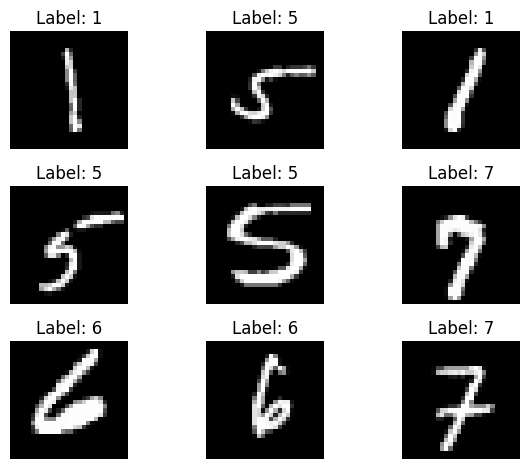

In [2]:
import matplotlib.pyplot as plt
import numpy as np

images = np.array(images)
labels = np.array(labels).ravel()

n_images = images.shape[0]
n_samples = 9

idx = np.random.choice(n_images, size = n_samples, replace = False)
images_sub = images[idx]
labels_sub = labels[idx]

fig, axes = plt.subplots(3, 3)

for i, ax in enumerate(axes.ravel()):
    img = images_sub[i].reshape(28,28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels_sub[i]}")
    ax.axis("off")

plt.tight_layout()

Digit = 1 | Train (n): 750, Test (n): 250, Train (%): 0.75
Digit = 5 | Train (n): 750, Test (n): 250, Train (%): 0.75
Digit = 7 | Train (n): 750, Test (n): 250, Train (%): 0.75


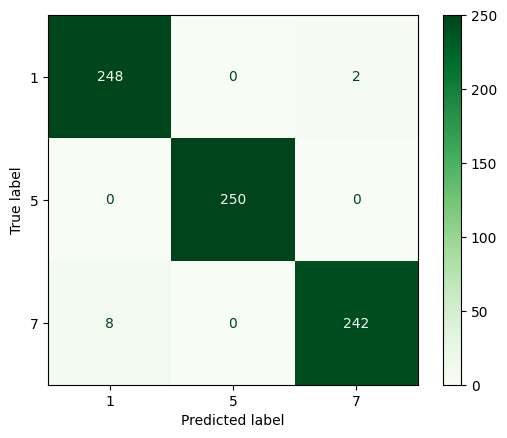

In [3]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Subet on three classes (NOTE: We are now doing the susbetting in numpy and not pandas)
digits = [1, 5, 7]
mask = (labels == digits[0]) | (labels == digits[1]) | (labels == digits[2]) 
images_sub = images[mask]
labels_sub = labels[mask]

# Create a test and train set
x_train, x_test, y_train, y_test = train_test_split(images_sub, labels_sub, test_size=0.25, stratify=labels_sub)

# Sanity check
for digit in digits:
    train_digits = np.sum(y_train == digit)
    test_digits = np.sum(y_test == digit)
    prop = train_digits / (train_digits + test_digits)
    print(f"Digit = {digit} | Train (n): {train_digits}, Test (n): {test_digits}, Train (%): {prop}")


# Apply to train
neigh = KNeighborsClassifier(n_neighbors=3)
neigh.fit(x_train, y_train)

# Predict on test data
preds = neigh.predict(x_test)

cm = confusion_matrix(y_test, preds, labels=digits)
ConfusionMatrixDisplay(cm, display_labels=digits).plot(cmap='Greens')




# Part 1

*Everyone should do this task.*

The purpose of this first exercise is to build a classification pipeline, from data exploration to validation. Remember to split your data into appropriate sets before you start.
You should explore at least 4 *different* classifiers of *different* character.

1. Perform dimension reduction on the data set. Is the data well separated?
2. Train the classifiers using the training data, and perform cross-validation to tune the models that require tuning.
3. Compare the performance of the different classifiers on a test set.

In [18]:
#split the data

#Is the data well seperated?

In [ ]:
#Split data into test and train
np.random.seed(42)
n = len(images)
train_idx = np.random.choice(n, n*0.6, replace=False)
test_idx = np.array([i for i in range(n) if i not in train_idx])

X_train_org = images[train_idx]
y_train = labels[train_idx]
X_test_org = images[test_idx]
y_test = labels[test_idx]


In [5]:
#Do SVD on training data
U_train, S_train, vt_train = np.linalg.svd(X_train_org, full_matrices = False)


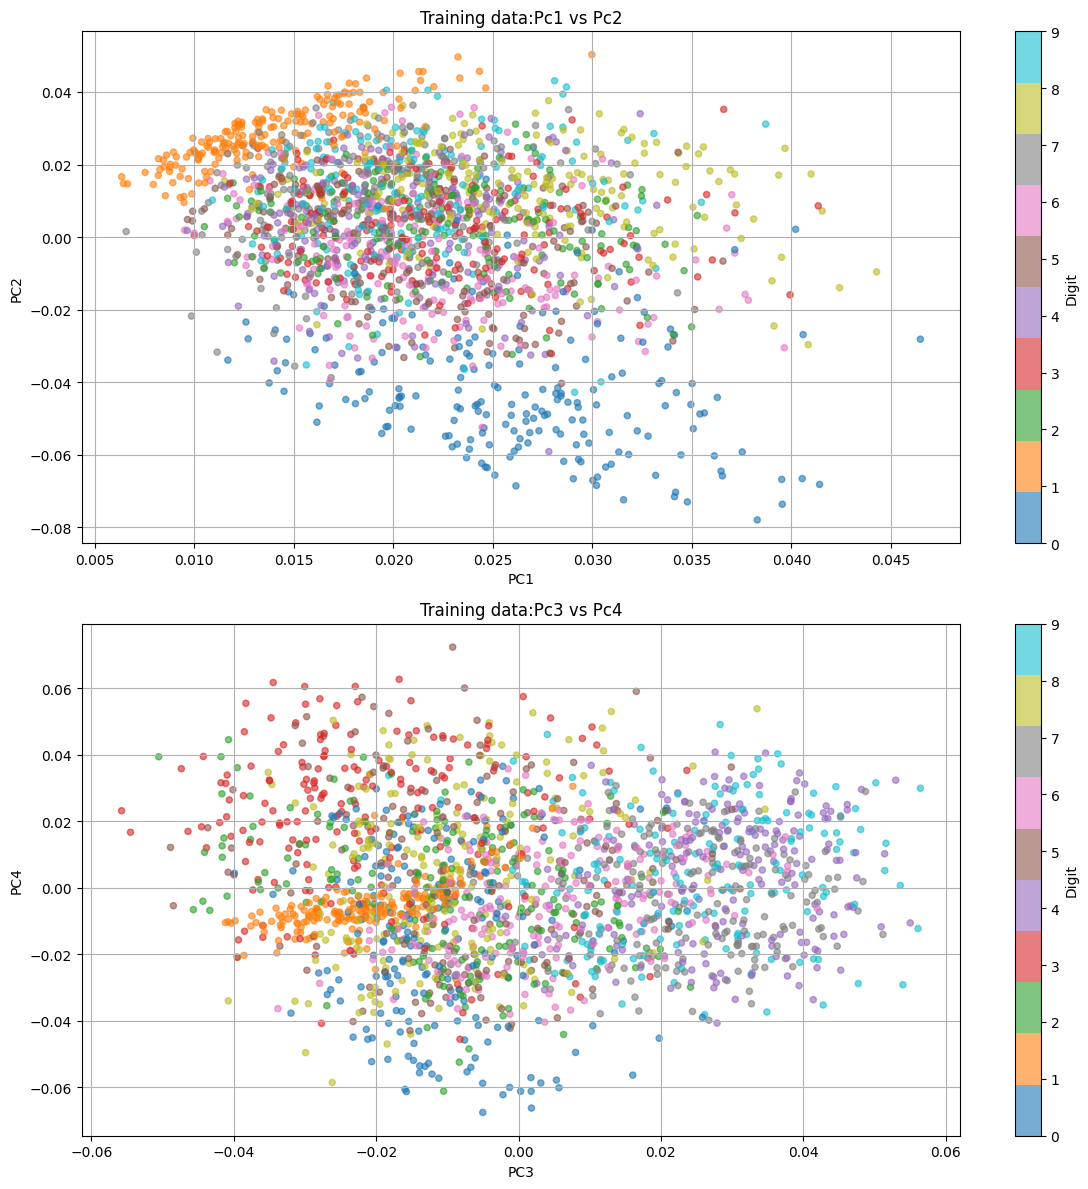

In [6]:
#Is the training data well seperated?
fig, ax = plt.subplots(2,1, figsize=(12, 12))
scatter = ax[0].scatter(U_train[:, 0], U_train[:, 1], c=y_train, cmap = 'tab10', s=20, alpha = 0.6)
ax[0].set_xlabel('PC1')
ax[0].set_ylabel('PC2')
ax[0].set_title('Training data:Pc1 vs Pc2')
plt.colorbar(scatter, label = 'Digit')
ax[0].grid(True)

scatter_2 = ax[1].scatter(U_train[:, 2], U_train[:, 3], c=y_train, cmap = 'tab10', s=20, alpha = 0.6)
ax[1].set_xlabel('PC3')
ax[1].set_ylabel('PC4')
ax[1].set_title('Training data:Pc3 vs Pc4')
plt.colorbar(scatter_2, label = 'Digit')
ax[1].grid(True)

plt.tight_layout()
plt.show()

#Some of them are well seperated (like 1 and 0), but most of them are not. We can see that the first 4 PCs are not enough to well seperate the data. We will need more patterns to do that.


In [ ]:
from matplotlib.patches import Patch
from sklearn import preprocessing.StandardScaler as StandardScaler
#General functions
#Function to calculate the new x_train and x_test with fewer patterns
def calc_reduced_pattern(U, S, vt, p_val, X_test_org, X_val_org):
    #Projected data:
    X_train_proj = U[:, :p_val] @ np.diag(S[:p_val])
    x_test_proj = X_test_org @ vt[:p_val, :].T
    x_val_proj = X_val_org @ vt[:p_val, :].T
    return X_train_proj, x_test_proj, x_val_proj

#Visualisation of how "wrong" the data is:
def visuale_error(x_axs, y_axs, x_name, y_name, title, results_val, ord_x, ord_y):
    #fig, ax = plt.subplots(1,2, figsize=(12, 6))

    #Effect of K
    colours = plt.cm.Set3(np.linspace(0, 1, len(x_axs)))
    bp_list = []

    for i, x_val in enumerate(x_axs):
        mask = results_val[:,ord_x] == x_val

        err_list = [results_val[mask, 2]] #Wrap in list
        pos = np.arange(len(y_axs)) + i*0.12 #Create single-value boxplots at multiple different positions


        for j, y_val in enumerate(y_axs):
            mask_y = (results_val[:,ord_x] == x_val) & (results_val[:,ord_y] == y_val)

            err_list_y = results_val[mask_y, 2]
            bp = plt.boxplot(err_list_y, positions=[pos[j]], widths = 0.1, patch_artist= True, boxprops = dict(facecolor=colours[i], alpha=0.7))


    plt.xlabel(y_name)
    plt.title(f'{title} error rate for different {x_name} and different {y_name}')
    plt.xticks(np.arange(len(y_axs))+0.5, [y_ax for y_ax in y_axs])
    plt.ylabel("Error rate")
    plt.grid(True, alpha = 0.3, axis = 'x')
    legend_elements = [Patch(facecolor = colours[i], alpha =0.7, label = f'{x_name} = {x_axs[i]}') for i in range(len(x_axs))]
    plt.legend(handles = legend_elements, loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()



def visuale_error_for_one(x_axs, x_name, title, results_val, ord_x):
    #fig, ax = plt.subplots(1,2, figsize=(12, 6))


    for i, x_val in enumerate(x_axs):
        mask = results_val[:,ord_x] == x_val

        err_list = [results_val[mask, 1]] #Wrap in list
        pos = np.arange(len(x_axs)) + i*0.12 #Create single-value boxplots at multiple different positions


        bp = plt.boxplot(err_list, positions=[pos[i]], widths = 0.1, patch_artist= True)


    plt.xlabel(x_name)
    plt.title(f'{title} error rate for different {x_name}')
    plt.xticks(np.arange(len(x_axs))+0.5, [x_ax for x_ax in x_axs])

    plt.ylabel("Error rate")
    plt.grid(True, alpha = 0.3, axis = 'x')
    plt.tight_layout()
    plt.show()


def compute_SVD(X, y, n):
    train_idx = np.random.choice(n, int(n * 0.6), replace=False)
    remaining = np.array([i for i in range(n) if i not in train_idx])
    val_idx = np.random.choice(remaining, int(n * 0.2), replace=False)
    test_idx = np.array([i for i in remaining if i not in val_idx])

    X_train = X[train_idx]
    y_train = y[train_idx]
    X_val = X[val_idx]
    y_val = y[val_idx]
    X_test = X[test_idx]
    y_test = y[test_idx]

    #X_mean = np.mean(X_train, axis=0)
    #X_train_centered = X_train - X_mean
    scaler = StandardScaler().fit(X_train)
    X_train_scaled = scaler.transform(X_train)
    x_val_scaled = scaler.transform(X_val)
    x_test_scaled = scaler.transform(X_test)

    U_train, S_train, vt_train = np.linalg.svd(X_train_scaled, full_matrices = False)

    return X_train_scaled, y_train, x_val_scaled, y_val, x_test_scaled, y_test, U_train, S_train, vt_train
#Is the scaling thing correct


In [16]:
def find_errors(x_vals, y_vals, results_val, results_test):
    errors = np.zeros((len(x_vals), len(y_vals)))
    smallest_err = np.inf
    best_comb = [0, 0]
    errors_list = []

    for i, x_val in enumerate(x_vals):
        for j, y_val in enumerate(y_vals):
            mask = (results_val[:, 0] == x_val) & (results_val[:, 1] == y_val)
            errors[i, j] = np.mean(results_val[mask, 2]) #Take the mean error across the B splits for this combination of P and k
            if errors[i, j] < smallest_err:
                smallest_err = errors[i, j] 
                best_comb = [x_val, y_val]
                errors_list = results_test[mask, 2]
    return smallest_err, best_comb, errors_list



In [24]:
"""Okay, so now we have the basic idea of the concept of how to do it
Next we need to do it with several different methods (4 different classifiers of 4 different characters)"""

'Okay, so now we have the basic idea of the concept of how to do it\nNext we need to do it with several different methods (4 different classifiers of 4 different characters)'

MAIN ONE: 

In [ ]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
import os

k_vals = [1,2,5,15]
P_vals = [2,10, 25, 50, 100]
N_vals = [10, 50, 100, 200]
B = 10 # num of splits

results_val_knn = []
results_test_knn = []

results_val_linear = []
results_test_linear = []

results_val_rfc = []
results_test_rfc = []

results_val_log = []
results_test_log = []

for b in range(B):
    print(f"b is {b}")
    x_train, y_train, x_val, y_val, x_test, y_test, U_train, S_train, vt_train = compute_SVD(images, labels, images.shape[0])
    for pp, p_val in enumerate(P_vals):
        print(f"p_val is {p_val}")
        x_train_proj, x_test_proj, x_val_proj = calc_reduced_pattern(U_train, S_train, vt_train, p_val, x_test, x_val)

        lda = LinearDiscriminantAnalysis()
        lda.fit(x_train_proj, y_train)

        pred_val_lda = lda.predict(x_val_proj)
        pred_test_lda = lda.predict(x_test_proj)

        err_val_linear = np.sum(pred_val_lda != y_val)/len(y_val)
        err_test_linear = np.sum(pred_test_lda != y_test) / len(y_test)

        results_val_linear.append([p_val, err_val_linear])
        results_test_linear.append([p_val, err_test_linear])

        log = LogisticRegression(max_iter=2000, solver = 'saga')
        log.fit(x_train_proj, y_train)

        pred_val_log = log.predict(x_val_proj)
        pred_test_log = log.predict(x_test_proj)

        err_val_log = np.sum(pred_val_log != y_val) / len(y_val)
        err_test_log = np.sum(pred_test_log != y_test) /len(y_test)

        results_val_log.append([p_val, err_val_log])
        results_test_log.append([p_val, err_test_log])


        for kk, k_val in enumerate(k_vals):
            #Use skleans KNeighbours Classifier
            knn = KNeighborsClassifier(n_neighbors=k_val)
            knn.fit(x_train_proj, y_train)
            pred_val = knn.predict(x_val_proj)
            pred_test = knn.predict(x_test_proj)

            #Compute error rates
            err_val = np.sum(pred_val != y_val) / len(y_val)
            err_test = np.sum(pred_test != y_test) /len(y_test)

            results_val_knn.append([p_val, k_val, err_val])
            results_test_knn.append([p_val, k_val, err_test])
        
        for nn, N_val in enumerate(N_vals):
            #Use skleans random tree classigier
            rfc = RandomForestClassifier(n_estimators=N_val)
            rfc.fit(x_train_proj, y_train)
            pred_val = rfc.predict(x_val_proj)
            pred_test = rfc.predict(x_test_proj)

            #Compute error rates
            err_val = np.sum(pred_val != y_val) / len(y_val)
            err_test = np.sum(pred_test != y_test) /len(y_test)

            results_val_rfc.append([p_val, N_val, err_val])
            results_test_rfc.append([p_val, N_val, err_test])

results_val_knn_upd = np.array(results_val_knn)
results_test_knn_upd = np.array(results_test_knn)

results_val_linear_upd = np.array(results_val_linear)
results_test_linear_upd = np.array(results_test_linear)

results_val_rfc_upd = np.array(results_val_rfc)
results_test_rfc_upd = np.array(results_test_rfc)

results_val_log_upd = np.array(results_val_log)
results_test_log_upd = np.array(results_test_log)


visuale_error(P_vals, k_vals, 'P', 'k', 'KNN', results_val_knn_upd, 0, 1)
visuale_error(k_vals, P_vals, 'k', 'P', 'KNN', results_val_knn_upd, 1, 0)

visuale_error(N_vals, k_vals, 'N', 'k', 'Random forrest', results_val_rfc_upd, 0, 1)
visuale_error(k_vals, N_vals, 'k', 'N', 'Random forrest method', results_val_rfc_upd, 1, 0)

visuale_error_for_one(P_vals, 'P', 'kNN', results_val_linear_upd, 0)

visuale_error_for_one(P_vals, 'P', 'Logistic regression', results_val_log_upd, 0)



smallest_err_linear, best_comb_linear, errors_list_linear = find_errors(P_vals, [1], results_val_linear_upd, results_test_linear_upd)
best_err_linear = np.mean(results_test_linear_upd[(results_test_linear_upd[:, 0] ==best_comb_linear[0])], 2)
print(f"Best combination: P= {best_comb_linear[0]} with error {best_err_linear} for linear")

smallest_err_log, best_com_log, errors_list_log = find_errors(P_vals, [1], results_val_log_upd, results_test_log_upd)
best_err_log = np.mean(results_test_log_upd[(results_test_log_upd[:, 0] == best_com_log[0]), 2])
print(f"Best combination: P= {best_com_log[0]} with error {best_err_log} for logistic regression")

smallest_err_knn, best_comb_knn, errors_list_knn = find_errors(P_vals, k_vals, results_val_knn_upd, results_test_knn_upd)
best_err_knn = np.mean(results_test_knn_upd[(results_test_knn_upd[:, 0] == best_comb_knn[0]) & (results_test_knn_upd[:, 1] == best_comb_knn[1]), 2])
print(f"Best combination: P={best_comb_knn[0]}, k={best_comb_knn[1]} with error {best_err_knn} for KNN")   

smallest_err_rfc, best_comb_rfc, errors_list_rfc = find_errors(N_vals, k_vals, results_val_rfc_upd, results_test_rfc_upd)
best_err_rfc = np.mean(results_test_rfc_upd[(results_test_rfc_upd[:, 0]==best_comb_rfc[0]) & (results_test_rfc_upd[:, 1]==best_comb_rfc[1]), 2])
print(f"Best combination: P={best_comb_rfc[0]}, N={best_comb_rfc[1]} with error {best_err_rfc} for RFC") 



b is 0
p_val is 2
p_val is 3
p_val is 10
p_val is 25
p_val is 50
p_val is 100


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


p_val is 200
b is 1
p_val is 2
p_val is 3
p_val is 10
p_val is 25
p_val is 50
p_val is 100


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


p_val is 200
b is 2
p_val is 2
p_val is 3
p_val is 10
p_val is 25
p_val is 50
p_val is 100


...

c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


p_val is 200
b is 8
p_val is 2
p_val is 3
p_val is 10
p_val is 25
p_val is 50
p_val is 100


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


p_val is 200


KeyboardInterrupt: 

In [21]:
#boxplot comparison of the 4 classifiers for all values of P, k, etc.
"""
import matplotlib.pyplot as plt 
import numpy as np

knn_data = results_val_knn_upd[:, 2]
lda_data = results_val_linear_upd[:, 1]
log_data = results_val_log_upd[:, 1]
rfc_data = results_val_rfc_upd[:, 2]

plot_data = [knn_data, lda_data, log_data, rfc_data]
labels = ["KNeigborsClassifier", "LinearDiscriminantAnalysis", "LogisticRegression", "RandomForestClassifier"]

plt.figure(figsize=(10,5))
plt.boxplot(plot_data, tick_labels=labels, patch_artist=True)
plt.ylabel("Validation error")
plt.title("Comparison of 4 classifiers")
plt.xticks(rotation=15)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
"""

'\nimport matplotlib.pyplot as plt \nimport numpy as np\n\nknn_data = results_val_knn_upd[:, 2]\nlda_data = results_val_linear_upd[:, 1]\nlog_data = results_val_log_upd[:, 1]\nrfc_data = results_val_rfc_upd[:, 2]\n\nplot_data = [knn_data, lda_data, log_data, rfc_data]\nlabels = ["KNeigborsClassifier", "LinearDiscriminantAnalysis", "LogisticRegression", "RandomForestClassifier"]\n\nplt.figure(figsize=(10,5))\nplt.boxplot(plot_data, tick_labels=labels, patch_artist=True)\nplt.ylabel("Validation error")\nplt.title("Comparison of 4 classifiers")\nplt.xticks(rotation=15)\nplt.grid(True, alpha=0.3)\nplt.tight_layout()\nplt.show()\n'

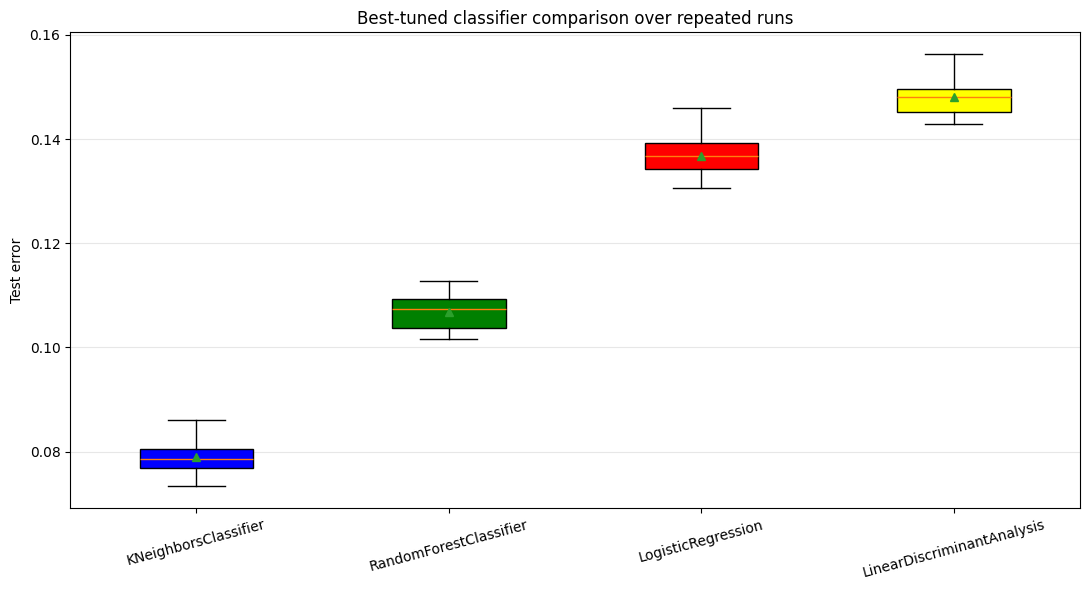

Best LDA: P = 100
Best Logistic Regression: P = 25
Best KNN: P = 50 , k = 1
Best Random Forest: P = 50 , N = 200

KNeighborsClassifier mean test error = 0.0789 std = 0.0034
RandomForestClassifier mean test error = 0.1068 std = 0.0033
LogisticRegression mean test error = 0.1368 std = 0.0035
LinearDiscriminantAnalysis mean test error = 0.148 std = 0.0034


In [ ]:
#finding the best parameters of the different classifiers to then compare it

#did this also because first boxplot version was too simple and compared over all average errors

#LDA and Logistic Regression tested over different P
#KNN is tested over different P and K
#Random Forest is tested over different P and N


best_p_lda = None
best_val_lda = np.inf

for p_val in P_vals:
    mask = results_val_linear_upd[:, 0] == p_val
    mean_error = np.mean(results_val_linear_upd[mask, 1])

    if mean_error < best_val_lda:
        best_val_lda = mean_error
        best_p_lda = p_val

lda_mask = results_test_linear_upd[:, 0] == best_p_lda
lda_best = results_test_linear_upd[lda_mask, 1]

best_p_log = None
best_val_log = np.inf

for p_val in P_vals:
    mask = results_val_log_upd[:, 0] == p_val
    mean_error = np.mean(results_val_log_upd[mask, 1])

    if mean_error < best_val_log:
        best_val_log = mean_error
        best_p_log = p_val

log_mask = results_test_log_upd[:, 0] == best_p_log
log_best = results_test_log_upd[log_mask, 1]

best_p_knn = None
best_k_knn = None
best_val_knn = np.inf

for p_val in P_vals:
    for k_val in k_vals:
        mask = (
            (results_val_knn_upd[:, 0] == p_val) &
            (results_val_knn_upd[:, 1] == k_val)
        )
        mean_error = np.mean(results_val_knn_upd[mask, 2])

        if mean_error < best_val_knn:
            best_val_knn = mean_error
            best_p_knn = p_val
            best_k_knn = k_val

knn_mask = (
    (results_test_knn_upd[:, 0] == best_p_knn) &
    (results_test_knn_upd[:, 1] == best_k_knn)
)
knn_best = results_test_knn_upd[knn_mask, 2]

best_p_rfc = None
best_n_rfc = None
best_val_rfc = np.inf

for p_val in P_vals:
    for n_val in N_vals:
        mask = (
            (results_val_rfc_upd[:, 0] == p_val) &
            (results_val_rfc_upd[:, 1] == n_val)
        )
        mean_error = np.mean(results_val_rfc_upd[mask, 2])

        if mean_error < best_val_rfc:
            best_val_rfc = mean_error
            best_p_rfc = p_val
            best_n_rfc = n_val

rfc_mask = (
    (results_test_rfc_upd[:, 0] == best_p_rfc) &
    (results_test_rfc_upd[:, 1] == best_n_rfc)
)
rfc_best = results_test_rfc_upd[rfc_mask, 2]


classifier_results = {
    "KNeighborsClassifier": knn_best,
    "LinearDiscriminantAnalysis": lda_best,
    "LogisticRegression": log_best,
    "RandomForestClassifier": rfc_best
}

ordered = sorted(
    classifier_results.keys(),
    key=lambda name: np.mean(classifier_results[name])
)

plot_data = [classifier_results[name] for name in ordered]

fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(
    plot_data,
    tick_labels=ordered,
    patch_artist=True,
    showmeans=True
)

colors = ["blue", "green", "red", "yellow"]
for box, color in zip(bp["boxes"], colors):
    box.set_facecolor(color)

ax.set_ylabel("Test error")
ax.set_title("Best-tuned classifier comparison over repeated runs")
ax.grid(True, alpha=0.3, axis="y")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

#added to show at where the best P value, it gives the lowest average(mean) validation error
print("Best LDA: P =", best_p_lda)
print("Best Logistic Regression: P =", best_p_log)
print("Best KNN: P =", best_p_knn, ", k =", best_k_knn)
print("Best Random Forest: P =", best_p_rfc, ", N =", best_n_rfc)
print()

for name in ordered:
    values = classifier_results[name]
    print(
        name,
        "mean test error =", round(np.mean(values), 4),
        "std =", round(np.std(values), 4) #how stable it is over runs
    )


## Part 2 - Themes
Choose ***one*** theme of the three and perform ***all*** tasks as described in this theme.

### Theme 1 - Class imbalance

For simplicity, restrict your data set to only 0s, 1s, and 2s. 

Create class imbalances in two different ways:
1. Keep the size of two classes and downsample the third.
2. Keep the size of one class and downsample the other two. 
You should explore at several levels of downsampling, from severe to mild. 

For each case, redo Part 1.

Compare class-specific accuracy and overall accuracy for the different classifiers. Do some models handle the downsampling better? In the most severe cases, can you see a reason to look at the class-specific accuracies and not just the overall accuracy?

### Theme 2 - Mislabeling

Create a mislabeled data set from the digits data by randomly changing the labels for some of the observations. *Note, you should only create mislabels for your training data - the test data should be clean.*

Redo Part 1 in this setting.

Which methods handle the mislabeling OK? which methods struggle?

You should explore at least 3 levels of mislabeling (some modest, some more severe and some really severe cases), i.e. proportion of mislabeled data. *Please note that your test data should be "clean", i.e. without mislabeling. For each simulation run, make sure you create a clean and separate data set to estimate prediction performance.*

### Theme 3 - Noise and dimension reduction

Add Gaussian noise to 10, 50, and 80 percent of the features (i.e. pixels). *Note, you should add the noise to both the training data and the test data.*

Choose 2 different dimension reduction methods and redo Part 1 with both, in addition to performing classification without any dimension reduction. (Consider how the variance of the noise and standardization of features may impact the outcome.)

How do the different dimension reduction methods compare? How do the different classifiers perform when the noise percentage is increased? Do any of them perform well without dimension reduction? Explain and discuss. 


In [32]:
#Part 2 code Theme 1 metric helpers, split and SVD helper


import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, confusion_matrix

images_df = pd.read_csv("mnist_large/images.csv", index_col=0)
labels_df = pd.read_csv("mnist_large/labels.csv", index_col=0)

images = images_df.to_numpy()
labels = labels_df.iloc[:, 0].to_numpy().ravel()

print("images shape:", images.shape)
print("labels shape:", labels.shape)
print("unique labels:", np.unique(labels))


#restructing the data set to digits 0, 1 and 2
def restrict_digits_012(X, y):
    mask = np.isin(y,[0, 1, 2])
    return X[mask], y[mask]

images_012, labels_012 = restrict_digits_012(images, labels)

print("images_012 shape:", images_012.shape)
print("labels_012 shape:", labels_012.shape)
for digit in [0, 1, 2]:
    print(f"class {digit} count:", np.sum(labels_012 == digit))

#create imbalance in 2 ways

#first way
#this for example keeps all 0, 1 and randomly keep some of 2. If one of these digits that we want to skring, keeps only a fraction of its rows else keeps all rows.

def make_imbalance_one_minority(X, y, minority_digit, minority_fraction, random_state=42):
    rng = np.random.default_rng(random_state)

    keep_indices = []

    for digit in [0, 1, 2]:
        digit_idx = np.where(y == digit)[0]

        if digit == minority_digit:
            n_keep = max(1, int(len(digit_idx) * minority_fraction))
            chosen = rng.choice(digit_idx, size=n_keep, replace=False)
            keep_indices.extend(chosen)
        else:
            keep_indices.extend(digit_idx)

    keep_indices = np.array(keep_indices)
    rng.shuffle(keep_indices)
    return X[keep_indices], y[keep_indices]


#second way
#this just does opposite so if the class is the one we want as the majority then it keep all of it. If it is not the majority class, then it keeps only a fraction of it. So for example if we want 0 to be the majority class, then we keep all 0 and only some of 1 and 2.

def make_imbalance_two_minorities(X, y, majority_digit, minority_fraction, random_state=42):
    rng = np.random.default_rng(random_state)

    keep_indices = []

    for digit in [0, 1, 2]:
        digit_idx = np.where(y == digit)[0]

        if digit == majority_digit:
            keep_indices.extend(digit_idx)
        else:
            n_keep = max(1, int(len(digit_idx) * minority_fraction))
            chosen = rng.choice(digit_idx, size=n_keep, replace=False)
            keep_indices.extend(chosen)
    
    keep_indices = np.array(keep_indices)
    rng.shuffle(keep_indices)
    return X[keep_indices], y[keep_indices]



#imbalance levels, not sure if this is good or not but here are some :)

imbalance_levels = [0.1, 0.2, 0.5, 0.8]

theme1_scenarios = [("one_minority", 2, 0.8, "one_minority_class2_mild"),
                    ("one_minority", 2, 0.5, "one_minority_class2_medium"),
                    ("one_minority", 2, 0.2, "one_minority_class2_severe"),
                    ("one_minority", 2, 0.1, "one_minority_class2_very_severe"),
                    ("two_minorities", 0, 0.8, "two_minorities_majority_mild"),
                    ("two_minorities", 0, 0.5, "two_minorities_majority_medium"),
                    ("two_minorities", 0, 0.2, "two_minorities_majority_severe"),
                    ("two_minorities", 0, 0.1, "two_minorities_majority_very_severe")]
print("theme1_scenarios:", theme1_scenarios)

#measuring model performance
def class_accuracy_from_labels(y_true, y_pred, class_order=(0, 1, 2)):
    cm = confusion_matrix(y_true, y_pred, labels=list(class_order)) #compares how many of 0, 1 and 2 were predicted correctly
    class_acc = {}

    for i, cls in enumerate(class_order):
        row_sum = cm[i].sum()
        class_acc[cls] = np.nan if row_sum == 0 else cm[i, i] / row_sum

    return class_acc

def evaluate_theme1_metrics(y_true, y_pred):
    overall_acc = accuracy_score(y_true, y_pred)
    balanced_acc = balanced_accuracy_score(y_true, y_pred)
    class_acc = class_accuracy_from_labels(y_true, y_pred)
    return overall_acc, balanced_acc, class_acc



#SVD and splitting the data into train, validation and test
def compute_SVD_theme1(X, y, train_fraction=0.6, val_fraction=0.2, random_state=42):
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=(1 - train_fraction), random_state=random_state, stratify=y)

    relative_val_fraction = val_fraction / (1 - train_fraction)

    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=(1 - relative_val_fraction), random_state=random_state, stratify=y_temp)

    X_mean = np.mean(X_train, axis=0)
    X_train_centered = X_train - X_mean
    X_val_centered = X_val - X_mean
    X_test_centered = X_test - X_mean

    U_train, S_train, vt_train = np.linalg.svd(X_train_centered, full_matrices=False)

    return X_train, y_train, X_val_centered, y_val, X_test_centered, y_test, U_train, S_train, vt_train

def class_count_dict(y):
    classes, counts = np.unique(y, return_counts=True)
    return {int(cls): int(cnt) for cls, cnt in zip(classes, counts)}

X_demo, y_demo = make_imbalance_one_minority(images_012, labels_012, minority_digit=2, minority_fraction=0.2, random_state=42)

print("Original counts:", class_count_dict(labels_012))
print("Imbalanced counts:", class_count_dict(y_demo))

images shape: (10000, 784)
labels shape: (10000,)
unique labels: [0 1 2 3 4 5 6 7 8 9]
images_012 shape: (3000, 784)
labels_012 shape: (3000,)
class 0 count: 1000
class 1 count: 1000
class 2 count: 1000
theme1_scenarios: [('one_minority', 2, 0.8, 'one_minority_class2_mild'), ('one_minority', 2, 0.5, 'one_minority_class2_medium'), ('one_minority', 2, 0.2, 'one_minority_class2_severe'), ('one_minority', 2, 0.1, 'one_minority_class2_very_severe'), ('two_minorities', 0, 0.8, 'two_minorities_majority_mild'), ('two_minorities', 0, 0.5, 'two_minorities_majority_medium'), ('two_minorities', 0, 0.2, 'two_minorities_majority_severe'), ('two_minorities', 0, 0.1, 'two_minorities_majority_very_severe')]
Original counts: {0: 1000, 1: 1000, 2: 1000}
Imbalanced counts: {0: 1000, 1: 1000, 2: 200}


In [ ]:
#Main code for theme 1, where we loop through the different scenarios and compute the metrics for each of them. 

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

k_vals = [1,2,5,10,25,50]
P_vals = [2,3,10, 25, 50, 100, 150, 200]
N_vals = [10, 50, 100, 200]
B = 25 # num of splits

#result lists
results_val_knn_theme1 = []
results_test_knn_theme1 = []

results_val_linear_theme1 = []
results_test_linear_theme1 = []

results_val_log_theme1 = []
results_test_log_theme1 = []

results_val_rfc_theme1 = []
results_test_rfc_theme1 = []

results_metrics_theme1 = []
results_counts_theme1 = []


#this will loop over each imbalance scenario and repeat that scenario over the number of splits(25)
#For each repeated run will it build the imbalanced data set, store the class counts and then does the train/validation/test split + SVD
for scenario_type, target_digit, minority_fraction, scenario_name in theme1_scenarios:
    print("Running scenario:", scenario_name)

    for b in range(B):
        random_state = 100 + b

        if scenario_type == "one_minority":
            X_use, y_use = make_imbalance_one_minority(images_012, labels_012, minority_digit=target_digit, minority_fraction=minority_fraction, random_state=random_state)
        else:
            X_use, y_use = make_imbalance_two_minorities(images_012, labels_012, majority_digit=target_digit, minority_fraction=minority_fraction, random_state=random_state)

        counts = class_count_dict(y_use)
        results_counts_theme1.append([scenario_name, scenario_type, target_digit, minority_fraction, b, counts.get(0, 0), counts.get(1, 0), counts.get(2, 0)])

        x_train, y_train, x_val, y_val, x_test, y_test, U_train, S_train, vt_train = compute_SVD_theme1(X_use, y_use, train_fraction=0.6, val_fraction=0.2,random_state=random_state)

        #Inside each run, it loops over p_val and trains all four classifiers on the reduced data
        for p_val in P_vals:
            x_train_proj, x_test_proj, x_val_proj = calc_reduced_pattern(U_train, S_train, vt_train, p_val, x_test, x_val)

            lda = LinearDiscriminantAnalysis()
            lda.fit(x_train_proj, y_train)
            pred_val_lda = lda.predict(x_val_proj)
            pred_test_lda = lda.predict(x_test_proj)

            err_val_linear = np.mean(pred_val_lda != y_val)
            err_test_linear = np.mean(pred_test_lda != y_test)

            results_val_linear_theme1.append([scenario_name, p_val, err_val_linear])
            results_test_linear_theme1.append([scenario_name, p_val, err_test_linear])

            overall_acc, balanced_acc, class_acc = evaluate_theme1_metrics(y_test, pred_test_lda)
            results_metrics_theme1.append([scenario_name, "LinearDiscriminantAnalysis", p_val, np.nan, np.nan, b,
            overall_acc, balanced_acc, class_acc[0], class_acc[1], class_acc[2]])

            log = LogisticRegression(max_iter=500, n_jobs=-1)
            log.fit(x_train_proj, y_train)
            pred_val_log = log.predict(x_val_proj)
            pred_test_log = log.predict(x_test_proj)

            err_val_log = np.mean(pred_val_log != y_val)
            err_test_log = np.mean(pred_test_log != y_test)

            results_val_log_theme1.append([scenario_name, p_val, err_val_log])
            results_test_log_theme1.append([scenario_name, p_val, err_test_log])

            overall_acc, balanced_acc, class_acc = evaluate_theme1_metrics(y_test, pred_test_log)
            results_metrics_theme1.append([scenario_name, "LogisticRegression", p_val, np.nan, np.nan, b,
            overall_acc, balanced_acc, class_acc[0], class_acc[1], class_acc[2]])

            for k_val in k_vals:
                knn = KNeighborsClassifier(n_neighbors=k_val, n_jobs=-1)
                knn.fit(x_train_proj, y_train)
                pred_val_knn = knn.predict(x_val_proj)
                pred_test_knn = knn.predict(x_test_proj)

                err_val_knn = np.mean(pred_val_knn != y_val)
                err_test_knn = np.mean(pred_test_knn != y_test)

                results_val_knn_theme1.append([scenario_name, p_val, k_val, err_val_knn])
                results_test_knn_theme1.append([scenario_name, p_val, k_val, err_test_knn])

                overall_acc, balanced_acc, class_acc = evaluate_theme1_metrics(y_test, pred_test_knn)
                results_metrics_theme1.append([scenario_name, "KNeighborsClassifier", p_val, k_val, np.nan, b,
                overall_acc, balanced_acc, class_acc[0], class_acc[1], class_acc[2]])

            for N_val in N_vals:
                rfc = RandomForestClassifier(n_estimators=N_val, n_jobs=-1, random_state=random_state)
                rfc.fit(x_train_proj, y_train)
                pred_val_rfc = rfc.predict(x_val_proj)
                pred_test_rfc = rfc.predict(x_test_proj)

                err_val_rfc = np.mean(pred_val_rfc != y_val)
                err_test_rfc = np.mean(pred_test_rfc != y_test)

                results_val_rfc_theme1.append([scenario_name, p_val, N_val, err_val_rfc])
                results_test_rfc_theme1.append([scenario_name, p_val, N_val, err_test_rfc])

                overall_acc, balanced_acc, class_acc = evaluate_theme1_metrics(y_test, pred_test_rfc)
                results_metrics_theme1.append([scenario_name, "RandomForestClassifier", p_val, np.nan, N_val, b,
                overall_acc, balanced_acc, class_acc[0], class_acc[1], class_acc[2]])


#converts the results to arrays and Dataframes
results_val_knn_theme1_update = np.array(results_val_knn_theme1, dtype=object)
results_test_knn_theme1_update = np.array(results_test_knn_theme1, dtype=object)

results_val_linear_theme1_update = np.array(results_val_linear_theme1, dtype=object)
results_test_linear_theme1_update = np.array(results_test_linear_theme1, dtype=object)

results_val_log_theme1_update = np.array(results_val_log_theme1, dtype=object)
results_test_log_theme1_update = np.array(results_test_log_theme1, dtype=object)

results_val_rfc_theme1_update = np.array(results_val_rfc_theme1, dtype=object)
results_test_rfc_theme1_update = np.array(results_test_rfc_theme1, dtype=object)

results_metrics_theme1_df = pd.DataFrame(results_metrics_theme1, columns=["scenario", "model", "p_val", "k_val", "N_val", "run","overall_accuracy", "balanced_accuracy","acc_class_0", "acc_class_1", "acc_class_2"])

results_counts_theme1_df = pd.DataFrame(results_counts_theme1, columns=["scenario", "scenario_type", "target_digit", "minority_fraction", "run", "count_0", "count_1", "count_2"])

results_metrics_theme1_df.head()

counts_summary = (results_counts_theme1_df.groupby(["scenario", "scenario_type", "target_digit", "minority_fraction"], as_index=False)[["count_0", "count_1", "count_2"]].mean())

print(counts_summary)


#plots

for _, row in counts_summary.iterrows():
    plt.figure(figsize=(6, 4))
    plt.bar(["0", "1", "2"],[row["count_0"], row["count_1"], row["count_2"]],color=["Blue", "Orange", "Green"])
    plt.title(f'Class counts: {row["scenario"]}')
    plt.xlabel("Class")
    plt.ylabel("Average count")
    plt.show()


scenario_to_plot = "one_minority_class2_severe"

knn_plot = results_val_knn_theme1_update[results_val_knn_theme1_update[:, 0] == scenario_to_plot][:, 1:]
rfc_plot = results_val_rfc_theme1_update[results_val_rfc_theme1_update[:, 0] == scenario_to_plot][:, 1:]
lda_plot = results_val_linear_theme1_update[results_val_linear_theme1_update[:, 0] == scenario_to_plot][:, 1:]
log_plot = results_val_log_theme1_update[results_val_log_theme1_update[:, 0] == scenario_to_plot][:, 1:]

knn_plot = knn_plot.astype(float)
rfc_plot = rfc_plot.astype(float)
lda_plot = lda_plot.astype(float)
log_plot = log_plot.astype(float)

visuale_error(P_vals, k_vals, 'P', 'k', f'KNN - {scenario_to_plot}', knn_plot, 0, 1)
visuale_error(N_vals, P_vals, 'N', 'P', f'Random forest - {scenario_to_plot}', rfc_plot, 1, 0)
visuale_error_for_one(P_vals, 'P', f'LDA - {scenario_to_plot}', lda_plot, 0)
visuale_error_for_one(P_vals, 'P', f'Logistic regression - {scenario_to_plot}', log_plot, 0)

summary_theme1 = (results_metrics_theme1_df.groupby(["scenario", "model", "p_val"], as_index=False)[["overall_accuracy", "balanced_accuracy", "acc_class_0", "acc_class_1", "acc_class_2"]].mean())

print(summary_theme1)

#boxplot of overall accuracy
p_val_best = 25
plot_df = results_metrics_theme1_df[results_metrics_theme1_df["p_val"] == p_val_best].copy()

plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_df, x="scenario", y="overall_accuracy", hue="model")
plt.title(f"Overall accuracy for Theme 1 (p={p_val_best})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#Boxplot of balanced accuracy
plt.figure(figsize=(14, 6))
sns.boxplot(data=plot_df, x="scenario", y="balanced_accuracy", hue="model")
plt.title(f"Balanced accuracy for Theme 1 (p={p_val_best})")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

#Boxplot of class specific accuracy
class_plot_df = plot_df.melt(id_vars=["scenario", "model", "p_val", "run"],value_vars=["acc_class_0", "acc_class_1", "acc_class_2"],var_name="class_name",value_name="class_accuracy")
class_plot_df["class_name"] = class_plot_df["class_name"].map({"acc_class_0": "Class 0","acc_class_1": "Class 1","acc_class_2": "Class 2",})
class_plot_df.head()

g = sns.catplot(data=class_plot_df,x="scenario",y="class_accuracy",hue="model",col="class_name",kind="box",height=5,aspect=1.2,sharey=True)
g.set_xticklabels(rotation=45)
g.fig.subplots_adjust(top=0.85)
g.fig.suptitle(f"Class-specific accuracy for Theme 1 (p={p_val_best})")
plt.show()


Running scenario: one_minority_class2_mild


C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be r

Running scenario: one_minority_class2_medium


C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iterati

Running scenario: one_minority_class2_severe


C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)
C:\Users\jeys_\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be r